<h1> EDA </h1>

In [15]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.feature_selection import mutual_info_regression

In [16]:
train = pd.read_csv("C:/Users/Ilias/documents/cours_mines/kaggle/customer_churn/train.csv", index_col='id')
train["Churn"] = (train["Churn"] == "Yes").astype(int)
train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


In [17]:
nan = train.isna().sum()
print(nan)
quantitatives = train.select_dtypes(include=np.number).columns.tolist()
qualitatives = train.select_dtypes(exclude=np.number).columns.tolist()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

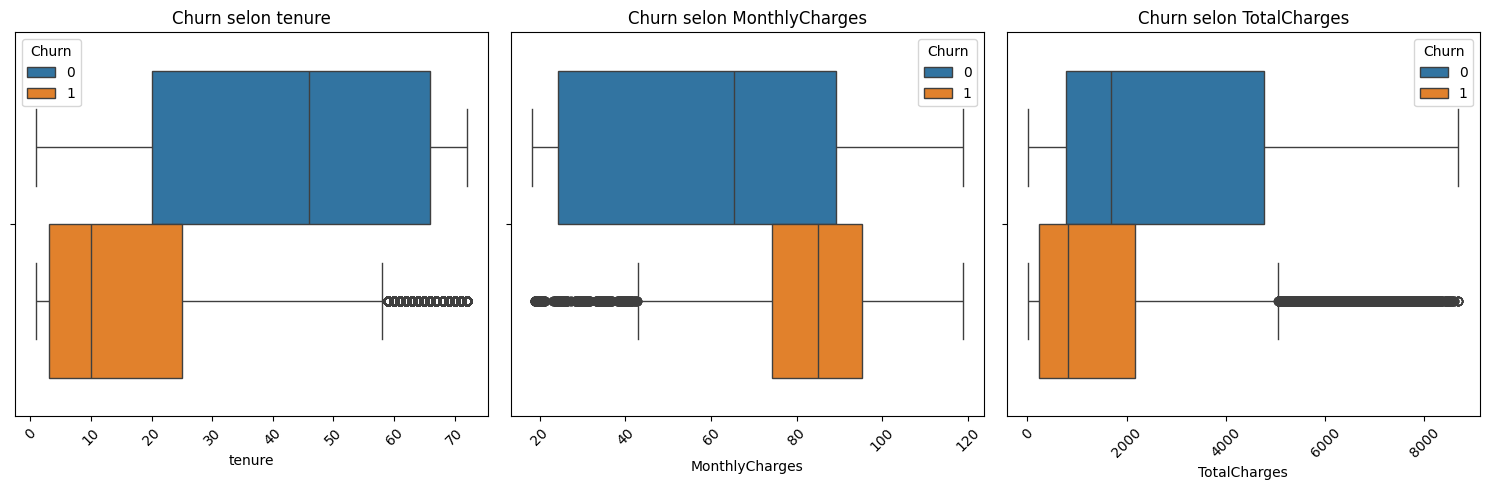

In [18]:
n_cols = 3
n_rows = math.ceil(len(quantitatives[1:-1]) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # pour itérer facilement

for i, y in enumerate(quantitatives[1:-1]):
    sns.boxplot(x=y, hue='Churn', data=train, ax=axes[i])
    axes[i].set_title(f'Churn selon {y}')
    axes[i].tick_params(axis='x', rotation=45)

# Supprimer les axes vides si besoin
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

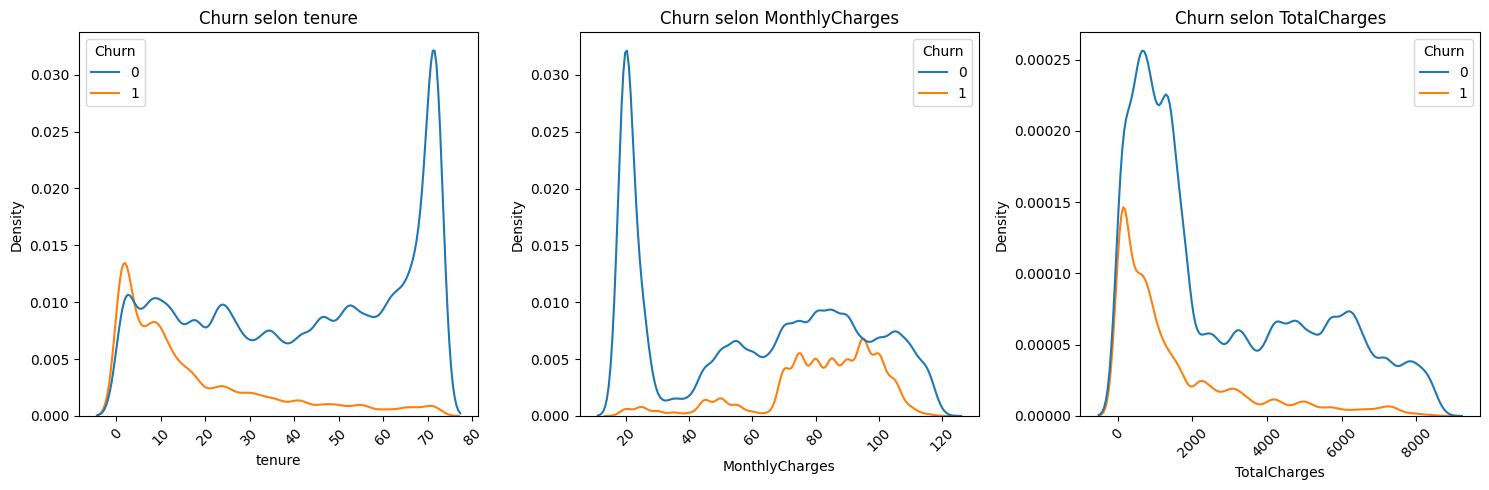

In [19]:
n_cols = 3
n_rows = math.ceil(len(quantitatives[1:-1]) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # pour itérer facilement

for i, y in enumerate(quantitatives[1:-1]):
    sns.kdeplot(x=y, hue='Churn', data=train, ax=axes[i])
    axes[i].set_title(f'Churn selon {y}')
    axes[i].tick_params(axis='x', rotation=45)

# Supprimer les axes vides si besoin
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show

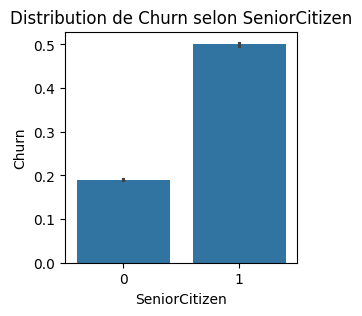

In [20]:
plt.figure(figsize=(3,3))
sns.barplot(x='SeniorCitizen', y='Churn', data=train)
plt.title('Distribution de Churn selon SeniorCitizen')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

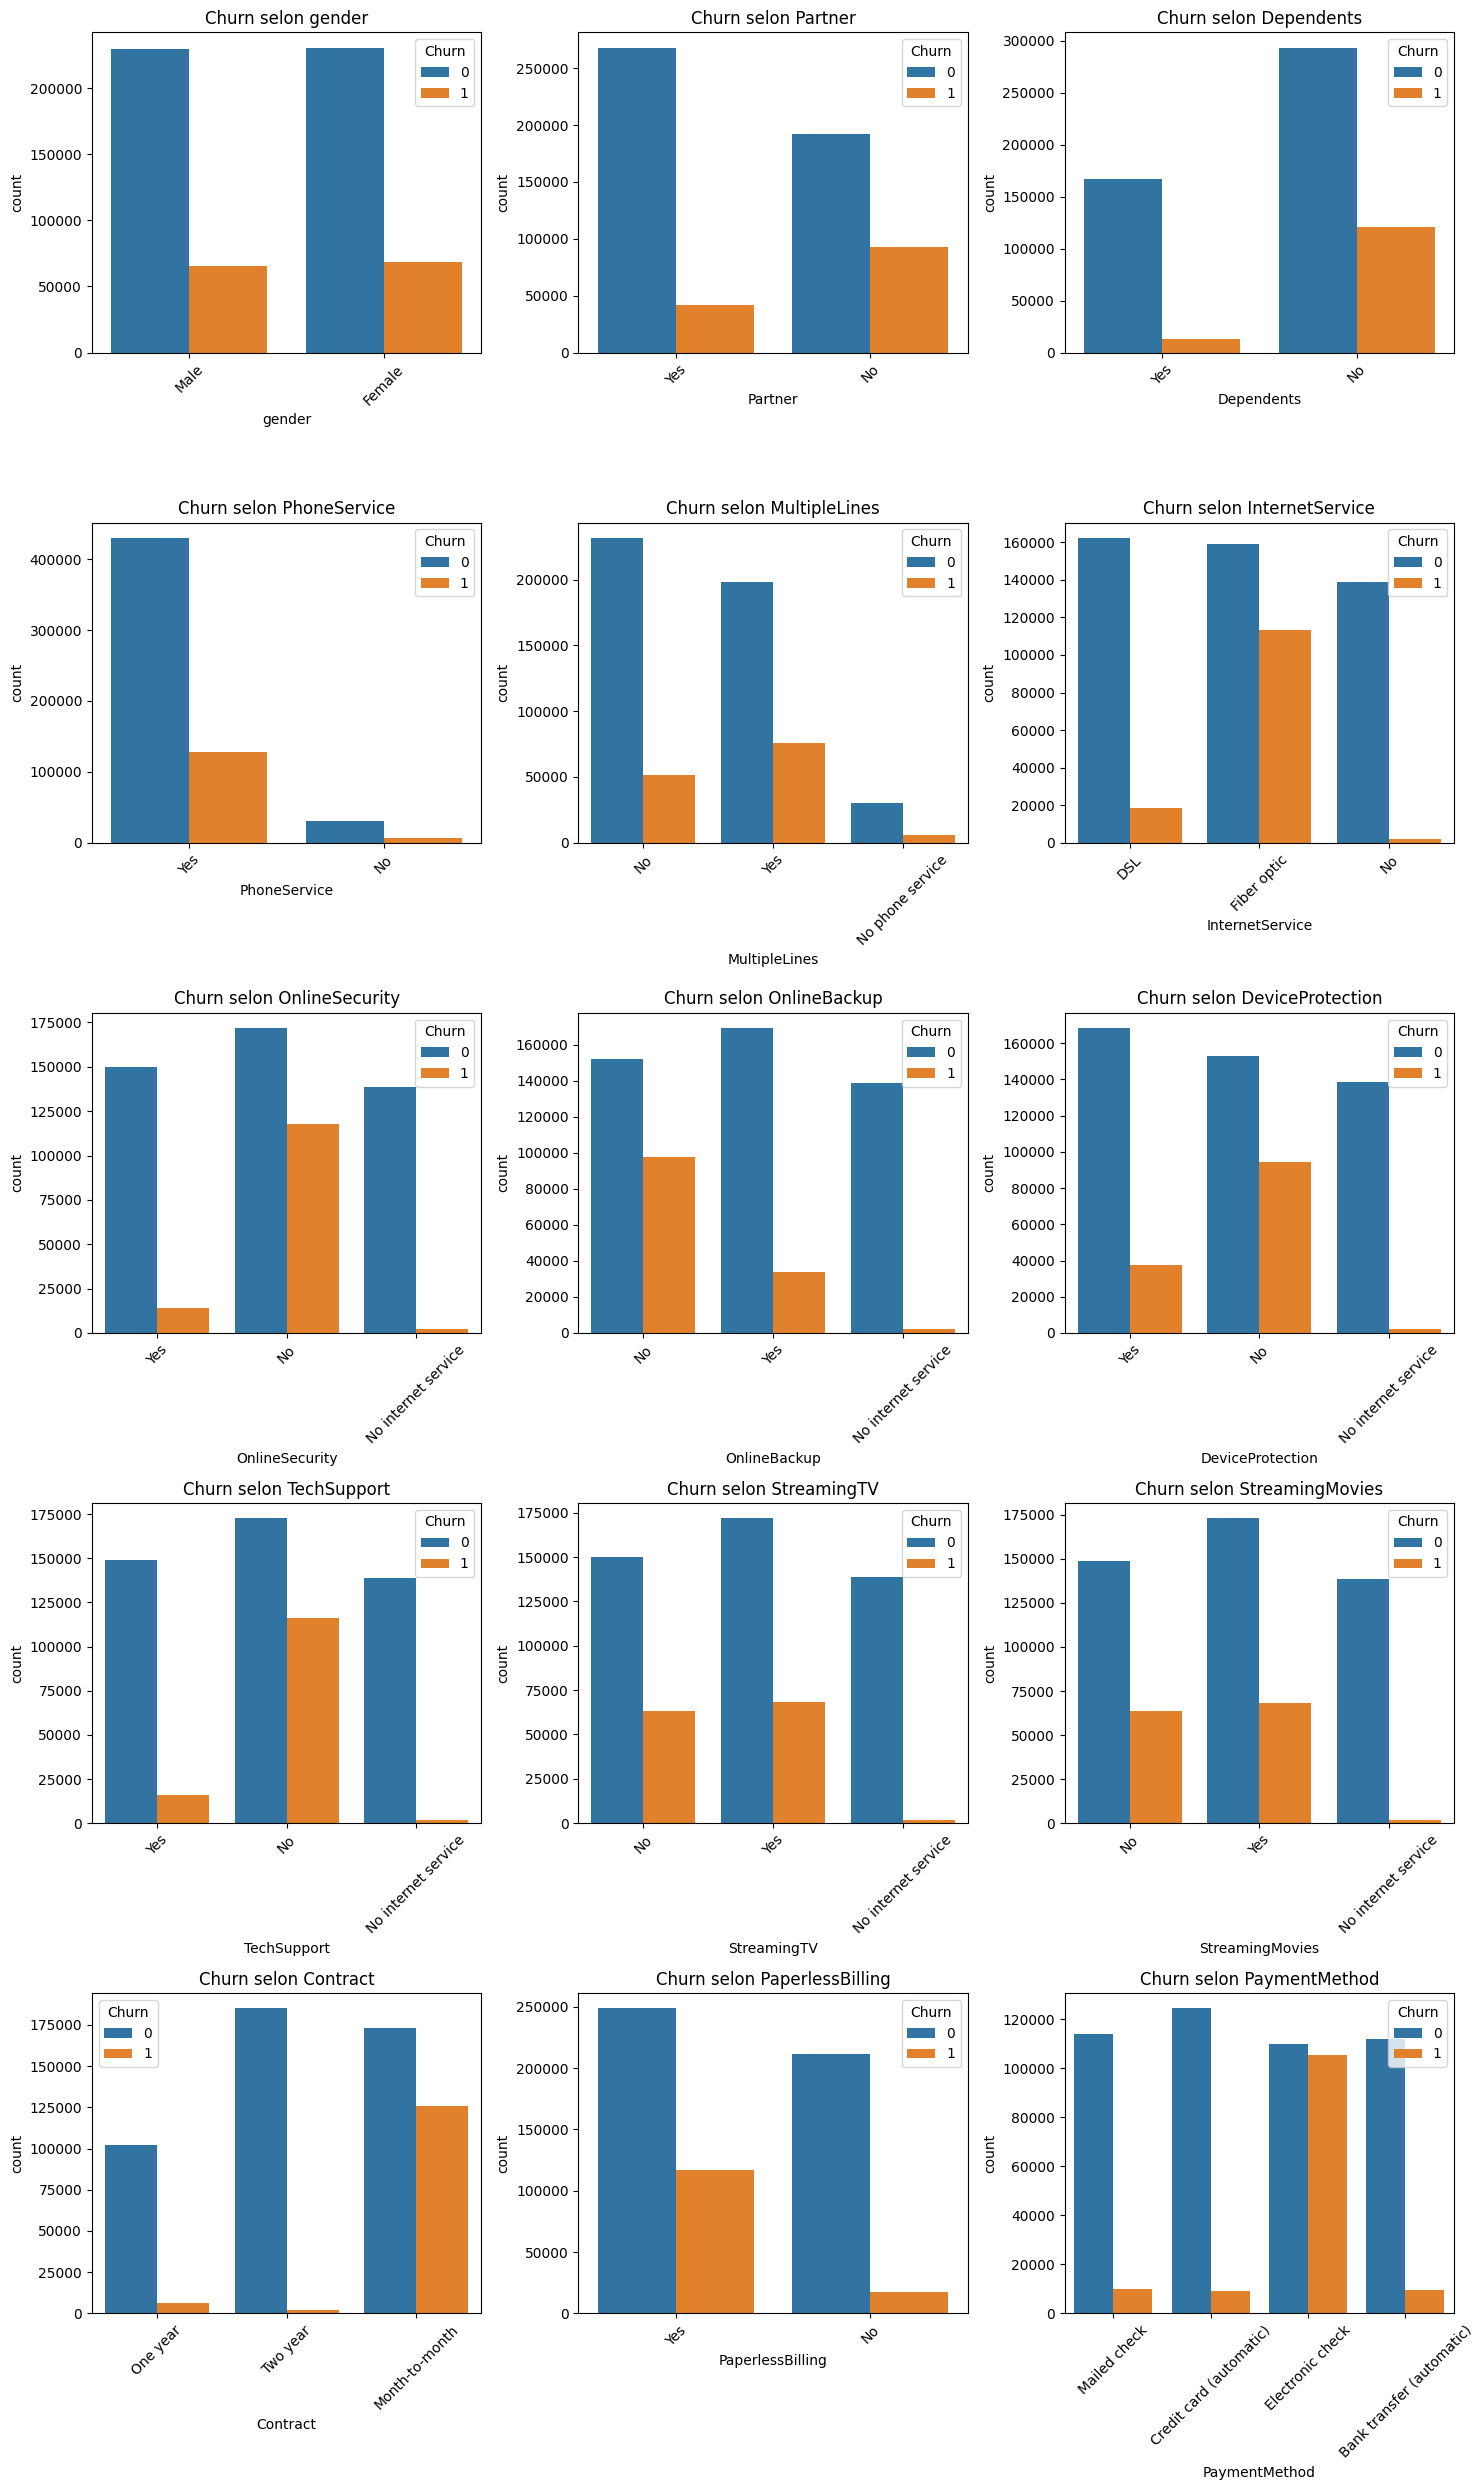

In [21]:
n_cols = 3
n_rows = math.ceil(len(qualitatives) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # pour itérer facilement

for i, y in enumerate(qualitatives):
    sns.countplot(x=y, hue='Churn', data=train, ax=axes[i])
    axes[i].set_title(f'Churn selon {y}')
    axes[i].tick_params(axis='x', rotation=45)

# Supprimer les axes vides si besoin
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show

In [22]:
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

X = train.copy()
y = X.pop("Churn")

# ici je calcule la mutual information score de chaque feature
mi_scores = make_mi_scores(X, y)
mi_scores

Contract            0.151722
TotalCharges        0.138701
PaymentMethod       0.125890
OnlineSecurity      0.120816
InternetService     0.117755
TechSupport         0.116635
tenure              0.106244
MonthlyCharges      0.094460
OnlineBackup        0.091045
DeviceProtection    0.084585
StreamingTV         0.066030
StreamingMovies     0.064953
PaperlessBilling    0.062496
Dependents          0.049758
Partner             0.037251
SeniorCitizen       0.036888
PhoneService        0.018686
MultipleLines       0.016711
gender              0.009816
Name: MI Scores, dtype: float64

- Contract : C'est la variable la plus discriminante ; les contrats sans engagement ("Month-to-month") concentrent l'écrasante majorité des résiliations.

- TotalCharges & tenure : Ces deux variables sont très corrélées et montrent clairement que le churn est un phénomène précoce (pic de résiliation dans les tout premiers mois d'abonnement).

- PaymentMethod : Les clients réglant leurs factures par "Electronic check" présentent un taux de churn anormalement élevé par rapport aux autres moyens de paiement.

- OnlineSecurity & TechSupport : Le fait de ne pas avoir souscrit à ces services d'accompagnement (tout en ayant internet) est un signal d'alerte majeur de départ.

- InternetService : Les abonnés disposant de la fibre optique résilient beaucoup plus massivement que ceux équipés de l'ADSL.

- MonthlyCharges : La distribution des densités indique que les clients qui résilient ont tendance à supporter des factures mensuelles plus élevées (pic visible entre 70 et 100).

- OnlineBackup & DeviceProtection : L'absence de ces options de protection augmente un peu le risque de départ.

- StreamingTV & StreamingMovies : Ces services de divertissement offrent un signal modéré, favorisant légèrement la rétention des clients qui en bénéficient.

- PaperlessBilling : Les clients ayant opté pour la facturation électronique sont légèrement plus volatils.

- Dependents & Partner : Les personnes seules ou sans enfants à charge sont un peu plus enclines à partir, mais le pouvoir prédictif global reste très modéré.

- SeniorCitizen : Bien que la proportion de churn soit très forte chez les seniors (~50%), ils représentent une trop petite minorité du dataset pour que la variable pèse lourdement dans le modèle global.

- PhoneService & MultipleLines : Ces variables ont peu de valeur ajoutée.

- gender : la proportion et le comportement de churn sont strictement identiques entre les hommes et les femmes, cette variable apporte principalement du bruit.

<h1> Feature Engineering </h1>

Commençons par l'encoding car il y a énormément de variables qualitatives dans ce dataset. On va encoder de manière binaire toutes les variables ayant 2 valeurs (Partner, Dependents, PhoneService, PaperlessBilling). 

Aussi, des variables (MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) apportent une colinéarité inutile (type 3 valeurs "yes", "no" et "no internet service" ou "no phone service"). On va donc mapper la 3ème valeur en "no" puis encoder en binaire. On perd aucune information en faisant ça donc je pense que ça marchera.

Pour le reste (Contract, PaymentMethod, InternetService) on va sûrement utiliser du one-hot encoding. Si ça fonctionne peu, j'essaierai d'encoder en faisant du target / mean encoding (en essayant d'éviter le data leakage !). Je suis pas sûr que ça aurait bcp de pluvalue parce que ces variables ont peu de valeurs prises (faible cardinalité).

In [23]:
bin_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in bin_cols:
    train[col] = train[col].map({'Yes': 1, 'No': 0})

multi_to_bin_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

train['gender'] = train['gender'].map({'Male': 1, 'Female': 0})

for col in multi_to_bin_cols:
    train[col] = train[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    train[col] = train[col].map({'Yes': 1, 'No': 0})

train = pd.get_dummies(train, columns=['Contract', 'PaymentMethod', 'InternetService'], drop_first=True)
train = train.astype({col: int for col in train.select_dtypes('bool').columns})

In [24]:
train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
id,,,,,,,,,,,,,,,,,,,,,
0,1,0,1,1,29,1,0,1,0,1,...,60.10,1653.85,0,1,0,0,0,1,0,0
1,1,0,1,1,58,1,0,1,1,0,...,69.50,3778.20,0,0,1,1,0,0,0,0
2,1,0,1,0,58,1,1,0,1,0,...,100.40,5841.35,0,0,0,0,1,0,1,0
3,0,0,0,0,1,1,0,0,0,0,...,69.70,70.70,1,0,0,0,1,0,1,0
4,0,0,0,0,1,1,0,0,0,0,...,70.45,70.45,1,0,0,0,1,0,1,0


In [25]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594194 entries, 0 to 594193
Data columns (total 24 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   gender                                 594194 non-null  int64  
 1   SeniorCitizen                          594194 non-null  int64  
 2   Partner                                594194 non-null  int64  
 3   Dependents                             594194 non-null  int64  
 4   tenure                                 594194 non-null  int64  
 5   PhoneService                           594194 non-null  int64  
 6   MultipleLines                          594194 non-null  int64  
 7   OnlineSecurity                         594194 non-null  int64  
 8   OnlineBackup                           594194 non-null  int64  
 9   DeviceProtection                       594194 non-null  int64  
 10  TechSupport                            594194 non-null  int64